In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import re
import os

# Set display options to show full content
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.expand_frame_repr', False)
# pd.set_option("display.max_rows", None)

# Model to predict the live weight, carcass weight, price, total number of defects
from sklearn.model_selection import train_test_split, cross_validate, KFold

# Model
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.metrics import make_scorer, mean_absolute_percentage_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from skopt.searchcv import BayesSearchCV
from skopt.space import Integer, Real
import joblib

import os
from scipy.stats import spearmanr

from sklearn.base import BaseEstimator, TransformerMixin

In [3]:
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.title_fontsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.frameon": False,
    "figure.figsize": (9, 3)  # standard size for subplots
})
COLORS = ['#5F6F52', '#A9B388', '#B99470']
COLORS2 = ['#395144', '#4E6C50', '#AA8B56']

In [4]:
# load preprocessed data files
beef = pd.read_csv('data/beef_preprocessed.csv')
beef['max_lag'] = (beef["Age"] * 30).astype(int)
df_lags = pd.read_csv('data/beef_weather_lags.csv')
data =  beef.join(df_lags)
RANDOM_STATE = 88888888

In [4]:
lags = [2, 3, 7, 14, 21, 30, 60, 90, 180, 360, 720]

pat = re.compile(r'__lag(\d+)_')
lag_features = {}
for c in df_lags.columns:
    m = pat.search(c)
    if m:
        d = int(m.group(1))
        lag_features.setdefault(d, []).append(c)

### Filter data into different lags to make sure there is no missing value in the filtered dataset

In [ ]:
# Build splits where, for each lag L, we first DROP all feature columns
# that come from larger lags (> L), THEN drop rows with any NaNs.

targets = ['live weight', 'carcass weight', 'price', 'Total number of defects']
drop_features = ['kill date', 'kill year', 'kill month', 'Processing location', 'Presentation Grade', 'Grade', 
                 'Teeth', 'Yield', 'Animal Type_num', 'Grade_num', 'Presentation Grade_num', 'Waste',
                 "price/kg", 'Animal Type', 'max_lag']

# Precompute: for each L, which lag-feature columns to drop (all from lags > L)
drop_larger_map = {}
for L in lags:
    cols_to_drop = []
    for d in lags:
        if d > L:
            cols_to_drop.extend(lag_features[d])  # from your dict
    drop_larger_map[L] = set(cols_to_drop)

splits = {}
for L in lags:
    base = data.loc[data['max_lag'] >= L].copy()

    # Targets first (keep as-is; we drop rows with NaNs later)
    y = base[targets].copy()

    # Features: start from base, drop meta cols, targets, and larger-lag features
    X = base.drop(columns=[*drop_features, *targets], errors="ignore")
    if drop_larger_map[L]:
        X = X.drop(columns=[c for c in drop_larger_map[L] if c in X.columns], errors="ignore")

    # Now drop rows with any NaNs across kept features + targets
    df_xy = pd.concat([X, y], axis=1).dropna(axis=0)
    X = df_xy.drop(columns=targets)
    y = df_xy[targets]

    # Save: (filtered_full_df, features, targets)
    splits[L] = (df_xy, X, y)

NameError: name 'lags' is not defined

## Which model performs best?

In [81]:
models = [
    ("Dummy Regressor", DummyRegressor(strategy='mean')),

    ("Decision Tree Unpruned", DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ("Decision Tree leaf 5",   DecisionTreeRegressor(random_state=RANDOM_STATE, min_samples_leaf=5)),
    ("Decision Tree leaf 10",  DecisionTreeRegressor(random_state=RANDOM_STATE, min_samples_leaf=10)),
    ("Decision Tree leaf 20",  DecisionTreeRegressor(random_state=RANDOM_STATE, min_samples_leaf=20)),

    ("Random Forest 50",  RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=50,  n_jobs=-1)),
    ("Random Forest 100", RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=100, n_jobs=-1)),
    ("Random Forest 200", RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200, n_jobs=-1)),

    # Scale-sensitive models wrapped in pipelines
    ("SVR(C=0.01)", Pipeline([("scaler", StandardScaler()), ("svr", SVR(C=0.01))])),
    ("SVR(C=0.1)",  Pipeline([("scaler", StandardScaler()), ("svr", SVR(C=0.1))])),
    ("SVR(C=1)",    Pipeline([("scaler", StandardScaler()), ("svr", SVR(C=1))])),

    ("LassoCV", Pipeline([("scaler", StandardScaler()), ("lasso", LassoCV(random_state=RANDOM_STATE))])),

    ("LightGBM 50",  LGBMRegressor(random_state=RANDOM_STATE, n_estimators=50,  n_jobs=-1)),
    ("LightGBM 100", LGBMRegressor(random_state=RANDOM_STATE, n_estimators=100, n_jobs=-1)),
    ("LightGBM 200", LGBMRegressor(random_state=RANDOM_STATE, n_estimators=200, n_jobs=-1)),

    ("Gradient Boosting 50",  GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=50)),
    ("Gradient Boosting 100", GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=100)),
    ("Gradient Boosting 200", GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=200)),
]

In [92]:
# RUN EXPERIMENTS

out_csv = "results/cv_results_on_animals_filtered_by_lag_availability.csv"
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
scoring = {"MAE": "neg_mean_absolute_error", "MSE": "neg_mean_squared_error"}

cv_obj = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for model_name, model in models:
    for lag in [3, 7, 14, 90, 180, 720]:
        X, Y = splits[lag][1], splits[lag][2]
        for target_name in Y.columns:
            rows = []
            for atype in ["cow", "steer", "heifer"]:
                mask = data.loc[X.index, "Animal Type"].astype(str).str.lower().eq(atype)
                idx = X.index[mask]
                if len(idx) < 5:
                    continue

                Xi, Yi = X.loc[idx], Y.loc[idx, target_name]
                cv = cross_validate(model, Xi, Yi, cv=cv_obj, scoring=scoring,
                                    return_train_score=True, n_jobs=-1)
                rows += [
                    {
                        "model_name": model_name,
                        "animal_type": atype,
                        "target": target_name,
                        "max_lag": lag,
                        "measure (MAE/MSE)": m,
                        "Cross-validation": i+1,
                        "evaluated_on (Train/Test)": s.capitalize(),
                        "Error": -cv[f"{s}_{m}"][i],
                    }
                    for m in ("MAE", "MSE")
                    for s in ("train", "test")
                    for i in range(cv_obj.get_n_splits())
                ]
            if rows:
                pd.DataFrame(rows).to_csv(
                    out_csv, mode="a", index=False, header=not os.path.exists(out_csv)
                )
            print("Completed", model_name, "|", lag, "days |", target_name)

Completed Dummy Regressor | 3 days | live weight
Completed Dummy Regressor | 3 days | carcass weight
Completed Dummy Regressor | 3 days | price
Completed Dummy Regressor | 3 days | Total number of defects
Completed Dummy Regressor | 7 days | live weight
Completed Dummy Regressor | 7 days | carcass weight
Completed Dummy Regressor | 7 days | price
Completed Dummy Regressor | 7 days | Total number of defects
Completed Dummy Regressor | 14 days | live weight
Completed Dummy Regressor | 14 days | carcass weight
Completed Dummy Regressor | 14 days | price
Completed Dummy Regressor | 14 days | Total number of defects
Completed Dummy Regressor | 90 days | live weight
Completed Dummy Regressor | 90 days | carcass weight
Completed Dummy Regressor | 90 days | price
Completed Dummy Regressor | 90 days | Total number of defects
Completed Dummy Regressor | 180 days | live weight
Completed Dummy Regressor | 180 days | carcass weight
Completed Dummy Regressor | 180 days | price
Completed Dummy Regres

In [159]:
df_res = pd.read_csv("results/cv_results_on_animals_filtered_by_lag_availability.csv")
df_res = df_res[df_res["evaluated_on (Train/Test)"].eq("Test")].copy()
df_res = df_res[df_res["measure (MAE/MSE)"].eq("MSE")].copy()
df_res = df_res[df_res["animal_type"] != "All"].copy()
df_res = df_res[df_res["target"] != "Total number of defects"].copy()

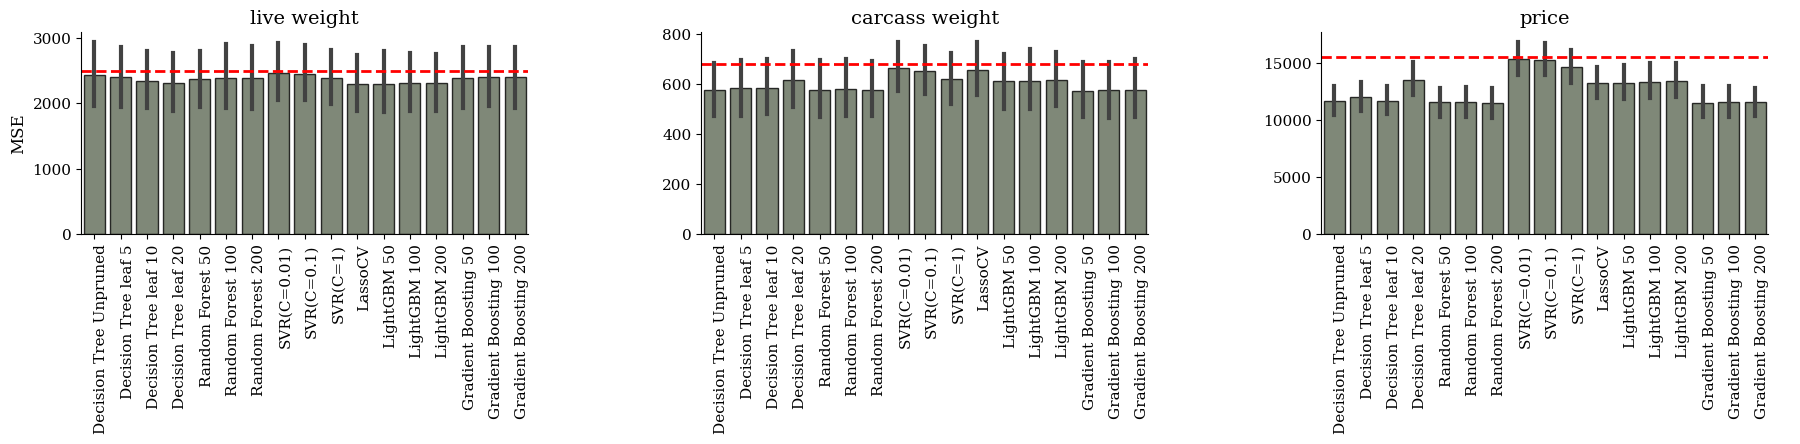

In [160]:
# Overall best models
g = sns.catplot(data=df_res[df_res['model_name'] != 'Dummy Regressor'], kind="bar", x="model_name", col="target", y="Error", 
                sharey=False, color=COLORS[0], alpha=0.8, edgecolor="black", height=3, aspect=2)
g.set_xticklabels(rotation=90, ha='right', rotation_mode='anchor')
g.set_axis_labels("", "MSE")
for tgt, ax in g.axes_dict.items():
    ax.set_title(f"{tgt}")

# baseline per target
baseline_means = df_res[df_res['model_name'] == 'Dummy Regressor'].groupby("target")["Error"].mean()
for ax in g.axes.flat:
    target = ax.get_title().split(" = ")[-1]
    ax.axhline(y=baseline_means[target], color="red", linestyle="--")

# Which lag length is important?

In [111]:
models = [
    ("Dummy Regressor", DummyRegressor(strategy='mean')),
    ("Random Forest", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ("LightGBM",  LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ("Gradient Boosting",  GradientBoostingRegressor(random_state=RANDOM_STATE)),
]

In [113]:
cv_obj = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"MAE": "neg_mean_absolute_error", "MSE": "neg_mean_squared_error"}
features = ["NZDI", "Transport distance (calculated)", "lairage time (calculated)", "Age"]

out_csv = "results/cv_results_on_animals_per_lag.csv"
if os.path.exists(out_csv):
    os.remove(out_csv)

for model_name, model in models:
    for lag in [7, 21, 90, 180]:
        feat_cols = [c for c in data.columns if f"__lag{lag}_" in c] + features
        base = data[feat_cols + targets + ["Animal Type"]].dropna()

        for target_name in targets:
            rows = []
            for atype in ["cow", "steer", "heifer"]:
                Xi = base.loc[base["Animal Type"].str.lower()==atype, feat_cols]
                Yi = base.loc[base["Animal Type"].str.lower()==atype, target_name]
                if len(Xi) < 5: 
                    continue

                est = model
                if model_name in {"Random Forest", "LightGBM", "Gradient Boosting"}:
                    est = BayesSearchCV(
                        model,
                        {"n_estimators": Integer(50, 300)},
                        n_iter=10,                  
                        cv=3,
                        scoring="neg_mean_squared_error",
                        n_jobs=-1,
                        random_state=RANDOM_STATE
                    )

                cv = cross_validate(est, Xi, Yi, cv=cv_obj, scoring=scoring,
                                    return_train_score=True, n_jobs=-1)
                for m in ("MAE", "MSE"):
                    for s in ("train", "test"):
                        for i in range(cv_obj.get_n_splits()):
                            rows.append({
                                "model_name": model_name, "animal_type": atype,
                                "target": target_name, "max_lag": lag,
                                "measure (MAE/MSE)": m, "Cross-validation": i+1,
                                "evaluated_on (Train/Test)": s.capitalize(),
                                "Error": -cv[f"{s}_{m}"][i],
                            })
            if rows:
                pd.DataFrame(rows).to_csv(out_csv, mode="a", index=False, header=not os.path.exists(out_csv))
        print("Completed", model_name, "| lag", lag, end="\r")


In [149]:
df_res = pd.read_csv("results/cv_results_on_animals_per_lag.csv")
df_res = df_res[df_res["evaluated_on (Train/Test)"].eq("Test")].copy()
df_res = df_res[df_res["measure (MAE/MSE)"].eq("MAE")].copy()
df_res = df_res[df_res["animal_type"] != "All"].copy()
df_res = df_res[df_res["target"] != "Total number of defects"].copy()
df_res2 = df_res[df_res['model_name'].isin(['Random Forest', 'Gradient Boosting', 'LightGBM'])].copy()

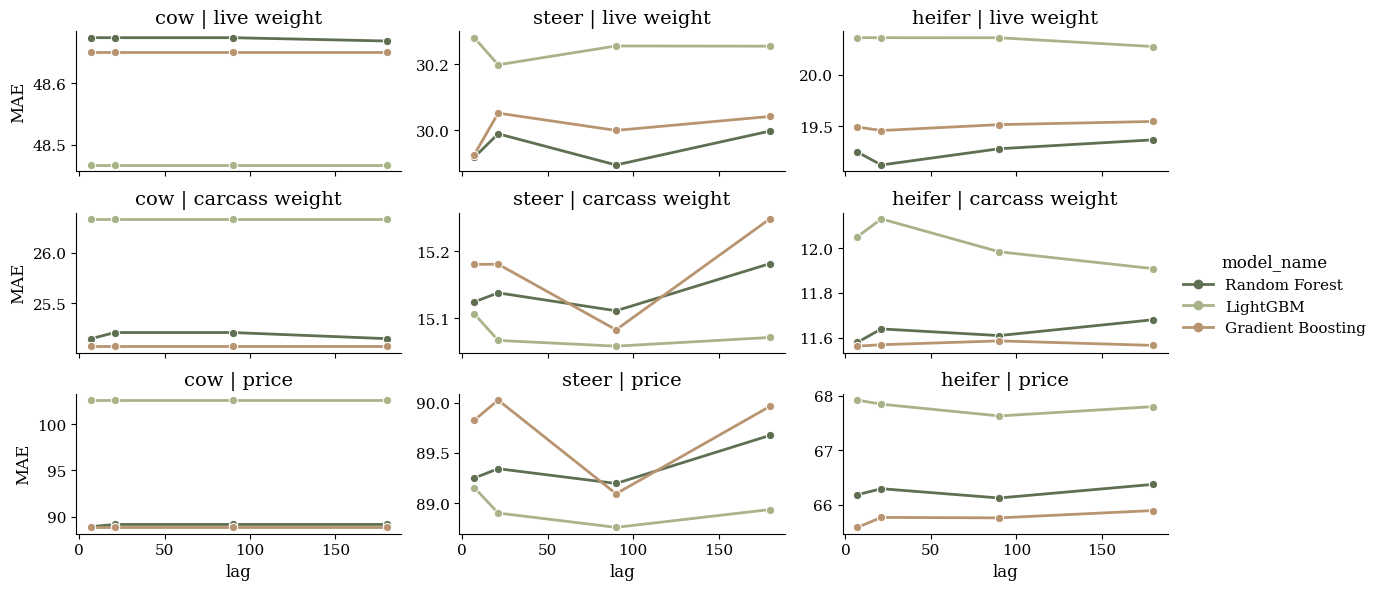

In [150]:
g = sns.relplot(
    data=df_res2, kind="line",
    x="max_lag", col="animal_type", row="target",
    hue="model_name", y="Error",
    height=2, aspect=2,
    palette=COLORS,
    facet_kws={"sharey": False},
    marker="o", errorbar=None
)
for (tgt, animal), ax in g.axes_dict.items():
    ax.set_title(f"{animal} | {tgt}")
g.set_axis_labels("lag", "MAE")


In [134]:
# aggregate per animal_type + target + model
agg = (
    df_res[df_res["evaluated_on (Train/Test)"].eq("Test") & 
           df_res["measure (MAE/MSE)"].eq("MSE")]
    .groupby(["animal_type", "target", "model_name"])["Error"]
    .mean()
    .reset_index()
)

# best model per animal_type + target
best_per_group = agg.loc[agg.groupby(["animal_type", "target"])["Error"].idxmin()]

# overall best model (lowest mean error across everything)
overall = agg.groupby("model_name")["Error"].mean().sort_values()
print("Overall best:\n", overall.head(1))

best_per_group, overall

Overall best:
 model_name
Gradient Boosting    4856.83867
Name: Error, dtype: float64


(   animal_type          target         model_name         Error
 1          cow  carcass weight  Gradient Boosting   1106.795709
 6          cow     live weight           LightGBM   3902.647185
 9          cow           price  Gradient Boosting  13515.148595
 13      heifer  carcass weight  Gradient Boosting    245.709532
 19      heifer     live weight      Random Forest    719.873699
 21      heifer           price  Gradient Boosting   7846.088468
 26       steer  carcass weight           LightGBM    387.442305
 31       steer     live weight      Random Forest   2093.371987
 34       steer           price           LightGBM  13486.366283,
 model_name
 Gradient Boosting    4856.838670
 Random Forest        4894.183845
 LightGBM             5469.717308
 Dummy Regressor      6178.192604
 Name: Error, dtype: float64)

## Most important features

In [173]:
targets = ["live weight", "carcass weight", "price"]
animals = ["cow", "steer", "heifer"]
base_feats = ["kill month", "Age", "Transport distance (calculated)", "lairage time (calculated)", "NZDI"]
lags = [2, 3, 7, 14, 21, 30, 60, 90]
lag_cols = [c for c in data.columns if any(f"__lag{d}_" in c for d in lags)]
feat_cols = base_feats + lag_cols

cv_inner = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
os.makedirs("models", exist_ok=True)

for animal in animals:
    df_sub = data.loc[data["Animal Type"].astype(str).str.lower().eq(animal)].dropna(subset=feat_cols + targets)
    X = df_sub[feat_cols].to_numpy()
    for t in targets:
        y = df_sub[t].to_numpy()
        if len(y) < 20:  # tiny guard
            continue

        search = BayesSearchCV(
            GradientBoostingRegressor(random_state=RANDOM_STATE),
            {
                "n_estimators": Integer(50, 200),
                "learning_rate": Real(0.01, 0.3, prior="log-uniform"),
                "max_depth": Integer(2, 6),
                "subsample": Real(0.6, 1.0)
            },
            n_iter=50, cv=cv_inner, scoring="neg_mean_absolute_error",
            n_jobs=-1, random_state=RANDOM_STATE, refit=True
        )

        search.fit(X, y)  # tunes on inner-CV, then refits best params on ALL rows
        print(f"[{animal} | {t}] best params:", search.best_params_)

        # save final model for later feature-importance analysis
        model_path = f"models/GBR_{animal.replace(' ','_')}_{t.replace(' ','_')}.joblib"
        joblib.dump(search.best_estimator_, model_path)

[cow | live weight] best params: OrderedDict({'learning_rate': 0.29999999999999993, 'max_depth': 4, 'n_estimators': 185, 'subsample': 0.777576534171366})


c:\Users\k_dos\Desktop\Weather_vs_CowHealth\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.29999999999999993, np.int64(4), np.int64(185), 0.6] before, using random point [0.03219269039819413, np.int64(4), np.int64(88), 0.8404099450762826]
  warnings.warn(


[cow | carcass weight] best params: OrderedDict({'learning_rate': 0.29999999999999993, 'max_depth': 6, 'n_estimators': 185, 'subsample': 0.6})
[cow | price] best params: OrderedDict({'learning_rate': 0.29999999999999993, 'max_depth': 4, 'n_estimators': 185, 'subsample': 0.6})
[steer | live weight] best params: OrderedDict({'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 153, 'subsample': 0.6})
[steer | carcass weight] best params: OrderedDict({'learning_rate': 0.02370183163977649, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.6})
[steer | price] best params: OrderedDict({'learning_rate': 0.01180803499529998, 'max_depth': 6, 'n_estimators': 151, 'subsample': 0.6})
[heifer | live weight] best params: OrderedDict({'learning_rate': 0.14623167297744807, 'max_depth': 2, 'n_estimators': 163, 'subsample': 0.6})
[heifer | carcass weight] best params: OrderedDict({'learning_rate': 0.014328580770976318, 'max_depth': 5, 'n_estimators': 93, 'subsample': 1.0})
[heifer | price] best para

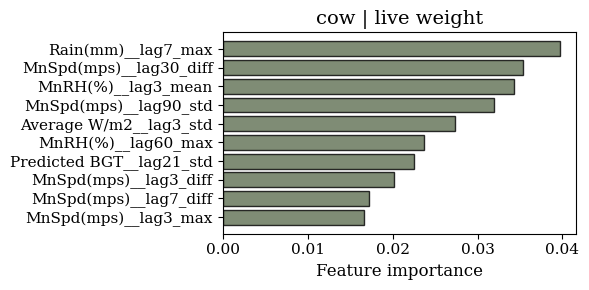

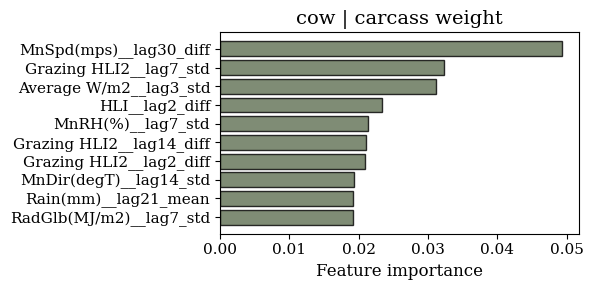

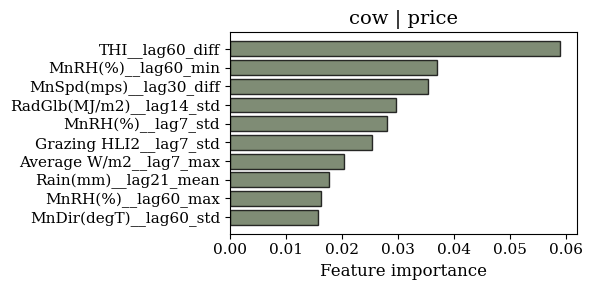

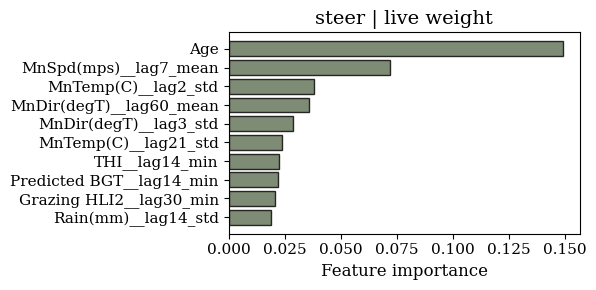

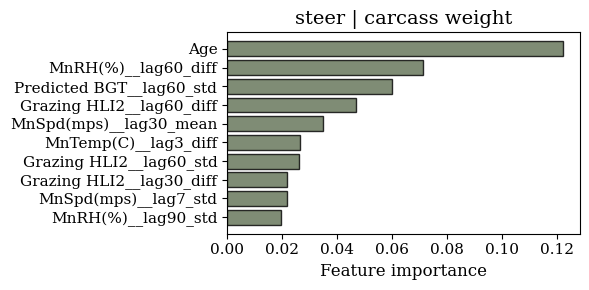

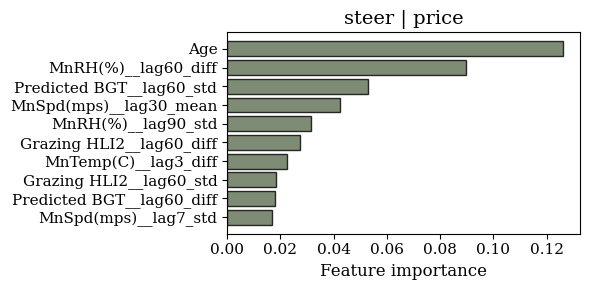

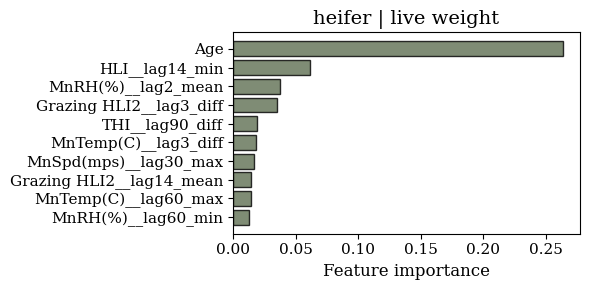

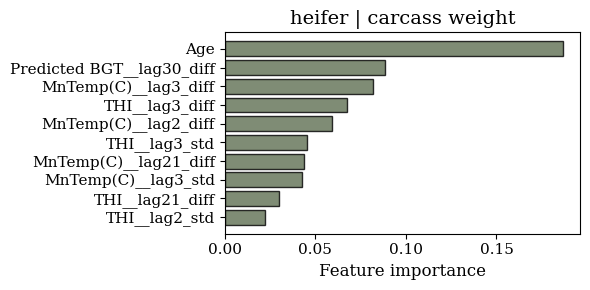

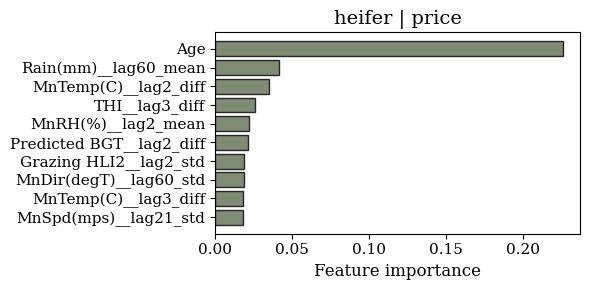

In [176]:
topx = 10
for animal in animals:
    for t in targets:
        model_path = f"models/GBR_{animal.replace(' ','_')}_{t.replace(' ','_')}.joblib"
        model = joblib.load(model_path)

        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:topx]
        top_feats = [feat_cols[i] for i in indices]
        top_vals = importances[indices]

        plt.figure(figsize=(6,0.3*topx))
        plt.barh(range(len(top_feats)), top_vals[::-1], edgecolor="black", alpha=0.8, color=COLORS[0])
        plt.yticks(range(len(top_feats)), top_feats[::-1])
        plt.xlabel("Feature importance")
        plt.title(f"{animal} | {t}")
        plt.tight_layout()
        plt.show()

# Windows

In [5]:
# load preprocessed data files
beef = pd.read_csv('data/beef_preprocessed.csv')
df_win = pd.read_csv('data/beef_weather_windows.csv')
data =  beef.join(df_win)

In [6]:
models = [
    ("Dummy Regressor", DummyRegressor(strategy='mean')),
    ("ElasticNetCV", Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9, 1.0],  # incl. Lasso
                             random_state=RANDOM_STATE))
    ])),
    ("SVR(C=1)", Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(C=1, kernel='rbf'))
    ])),
    ("SVR(C=3)", Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(C=3, kernel='rbf'))
    ])),
    ("Random Forest depth4", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_estimators=200,
        max_depth=4,
        n_jobs=-1
    )),
    ("Random Forest depth6", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_estimators=200,
        max_depth=6,
        n_jobs=-1
    )),
    ("LightGBM depth4", LGBMRegressor(
        random_state=RANDOM_STATE,
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        n_jobs=-1
    )),
    ("LightGBM depth6", LGBMRegressor(
        random_state=RANDOM_STATE,
        n_estimators=150,
        max_depth=6,
        learning_rate=0.05,
        n_jobs=-1
    )),
    ("Gradient Boosting 100", GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        n_estimators=100,
        max_depth=3
    )),
]


In [9]:
# Build splits for windows data by dropping rows with NaNs

targets = ['live weight', 'carcass weight', 'price', 'Total number of defects']
drop_features = ['kill date', 'kill year', 'kill month', 'Processing location', 'Presentation Grade', 'Grade', 
                 'Teeth', 'Yield', 'Animal Type_num', 'Grade_num', 'Presentation Grade_num', 'Waste',
                 "price/kg", 'Animal Type', 'max_lag', 'Age']

splits = {}
# For windows, use all available window features (no hierarchical lag structure)
X = data.drop(columns=[*drop_features, *targets], errors="ignore")
y = data[targets].copy()

# Drop rows with any NaNs across features + targets
df_xy = pd.concat([X, y], axis=1).dropna(axis=0)
X = df_xy.drop(columns=targets)
y = df_xy[targets]

# Store the single split for windows analysis
splits['windows'] = (df_xy, X, y)

In [11]:
# -------------------------------------------------------------------
# RUN EXPERIMENTS on windows
# -------------------------------------------------------------------
out_csv = "results/cv_results_on_animals_windows.csv"
os.makedirs(os.path.dirname(out_csv), exist_ok=True)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
}

cv_obj = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_full, Y_full = splits['windows'][1], splits['windows'][2]

for model_name, model in models:
    for target_name in Y_full.columns:
        rows = []

        for atype in ["cow", "steer", "heifer"]:
            mask = (
                data.loc[X_full.index, "Animal Type"]
                .astype(str)
                .str.lower()
                .eq(atype)
            )
            idx = X_full.index[mask]
            if len(idx) < 5:
                continue

            Xi = X_full.loc[idx]
            Yi = Y_full.loc[idx, target_name]

            cv = cross_validate(
                model,
                Xi,
                Yi,
                cv=cv_obj,
                scoring=scoring,
                return_train_score=True,
                n_jobs=-1,
            )

            rows += [
                {
                    "model_name": model_name,
                    "animal_type": atype,
                    "target": target_name,
                    "measure (MAE/MSE)": m,
                    "Cross-validation": i + 1,
                    "evaluated_on (Train/Test)": s.capitalize(),
                    "Error": -cv[f"{s}_{m}"][i],
                }
                for m in ("MAE", "MSE")
                for s in ("train", "test")
                for i in range(cv_obj.get_n_splits())
            ]

        if rows:
            pd.DataFrame(rows).to_csv(
                out_csv,
                mode="a",
                index=False,
                header=not os.path.exists(out_csv),
            )

        print("Completed", model_name, "|", target_name)


Completed Dummy Regressor | live weight
Completed Dummy Regressor | carcass weight
Completed Dummy Regressor | price
Completed Dummy Regressor | Total number of defects
Completed ElasticNetCV | live weight
Completed ElasticNetCV | carcass weight
Completed ElasticNetCV | price
Completed ElasticNetCV | Total number of defects
Completed SVR(C=1) | live weight
Completed SVR(C=1) | carcass weight
Completed SVR(C=1) | price
Completed SVR(C=1) | Total number of defects
Completed SVR(C=3) | live weight
Completed SVR(C=3) | carcass weight
Completed SVR(C=3) | price
Completed SVR(C=3) | Total number of defects
Completed Random Forest depth4 | live weight
Completed Random Forest depth4 | carcass weight
Completed Random Forest depth4 | price
Completed Random Forest depth4 | Total number of defects
Completed Random Forest depth6 | live weight
Completed Random Forest depth6 | carcass weight
Completed Random Forest depth6 | price
Completed Random Forest depth6 | Total number of defects
Completed Ligh

In [14]:
df_res = pd.read_csv("results/cv_results_on_animals_windows.csv")
df_res = df_res[df_res["evaluated_on (Train/Test)"].eq("Test")].copy()
df_res = df_res[df_res["measure (MAE/MSE)"].eq("MAE")].copy()
df_res = df_res[df_res["animal_type"] != "All"].copy()
df_res = df_res[df_res["target"] != "Total number of defects"].copy()

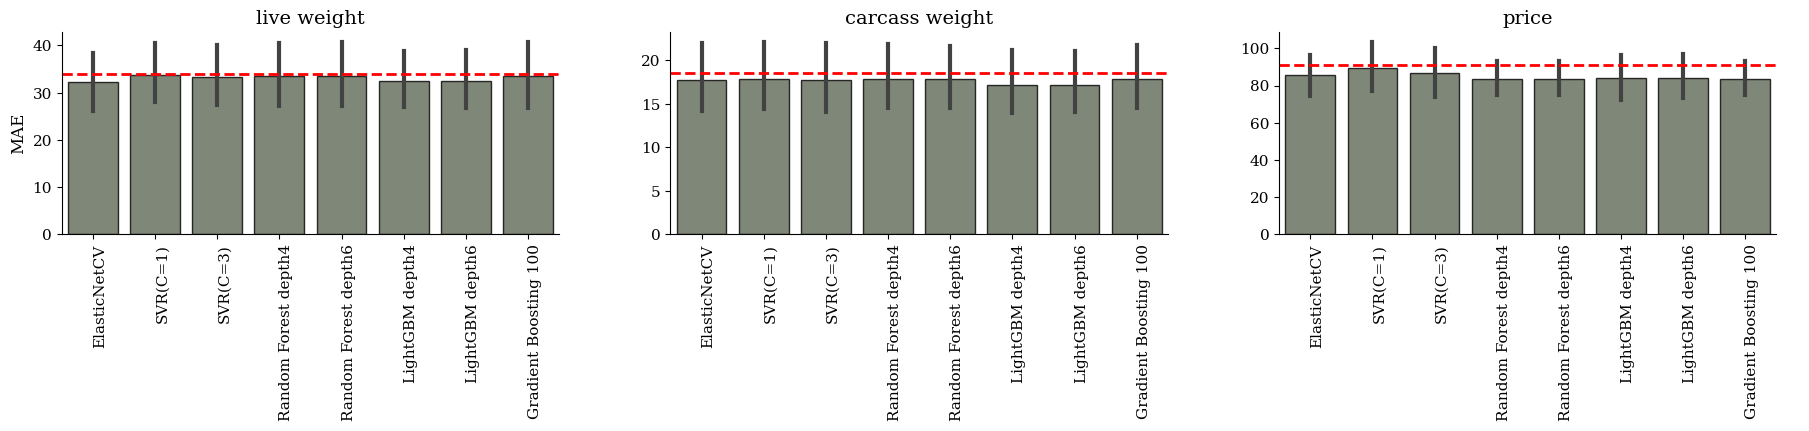

In [15]:
# Overall best models
g = sns.catplot(data=df_res[df_res['model_name'] != 'Dummy Regressor'], kind="bar", x="model_name", col="target", y="Error", 
                sharey=False, color=COLORS[0], alpha=0.8, edgecolor="black", height=3, aspect=2)
g.set_xticklabels(rotation=90, ha='right', rotation_mode='anchor')
g.set_axis_labels("", "MAE")
for tgt, ax in g.axes_dict.items():
    ax.set_title(f"{tgt}")

# baseline per target
baseline_means = df_res[df_res['model_name'] == 'Dummy Regressor'].groupby("target")["Error"].mean()
for ax in g.axes.flat:
    target = ax.get_title().split(" = ")[-1]
    ax.axhline(y=baseline_means[target], color="red", linestyle="--")